# Fase 3 — Análisis Visual e Insights
## Dataset: ABC Corporation — HR Analytics

**Objetivo:** Cada gráfica responde a una pregunta real de negocio de ABC Corporation.
No graficamos por graficar, sino para aportar respuestas.

**Estructura:**
- Pregunta 1 — ¿Por qué se van los empleados?
- Pregunta 2 — ¿Influye el sueldo?
- Pregunta 3 — ¿Influye el sexo o la edad?
- Pregunta 4 — ¿Influye el rol o la distancia?
- Pregunta 5 — ¿Qué hace que un empleado esté cómodo?
- Bonus — Modelo predictivo (Random Forest)

**Enfoque clave para la demo:** Empezar siempre planteando la pregunta de negocio en voz alta,
mostrar la gráfica y cerrar con la conclusión extraída.

---

## Configuración inicial e identidad visual

In [1]:
# Librerías para visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo general
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'figure.figsize': [10, 6]
})

# Paleta de colores corporativa
# PALETA_FUGA: gris para empleados que se quedan (0), rojo para los que se van (1)
PALETA_FUGA = {0: '#7B8A98', 1: '#FF6B6B'}
VERDE = '#639922'
ROJO  = '#E24B4A'
AZUL  = '#378ADD'
GRIS  = '#B4B2A9'

# Factor de conversión cm a pulgadas
cm = 1 / 2.54

print('Entorno de visualización configurado.')

Entorno de visualización configurado.


## Carga del dataset limpio

In [2]:
# Cargamos el CSV limpio generado en la Fase 2
df = pd.read_csv('hr_clean.csv')

print(f'Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas')

# Filtramos filas con Department 'Unknown' para las visualizaciones
# (son nulos que se imputaron con moda en Fase 2 — no aportan valor visual)
df_grafico = df[df['Department'] != 'Unknown'].copy()

print(f'Dataset para gráficos: {df_grafico.shape[0]} filas')
df.head(3)

Dataset cargado: 1470 filas y 32 columnas
Dataset para gráficos: 1470 filas


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0


---
## Pregunta 1 — ¿Por qué se van los empleados?
### Gráfica 1 — Attrition por departamento

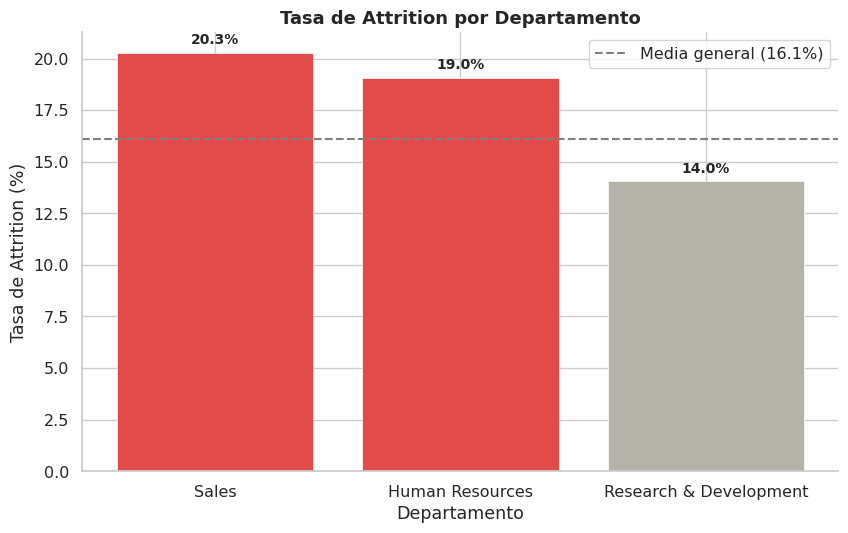

In [4]:
# Calculamos el porcentaje de attrition por departamento
attrition_dept = (
    df_grafico.groupby('Department')['Attrition']
    .mean() * 100
).sort_values(ascending=False).reset_index()
attrition_dept.columns = ['Department', 'Attrition_pct']

# Asignamos colores según si supera la media general
media_general = df_grafico['Attrition'].mean() * 100
colores = [ROJO if v > media_general else GRIS for v in attrition_dept['Attrition_pct']]

# Dibujamos el gráfico
fig, ax = plt.subplots(figsize=(22*cm, 14*cm))
bars = ax.bar(attrition_dept['Department'], attrition_dept['Attrition_pct'],
              color=colores, edgecolor='white', linewidth=0.5)

# Añadimos etiquetas de valor encima de cada barra
for bar, val in zip(bars, attrition_dept['Attrition_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Línea de media general
ax.axhline(y=media_general, color='gray', linestyle='--',
           linewidth=1.5, label=f'Media general ({media_general:.1f}%)')

ax.set_title('Tasa de Attrition por Departamento', fontweight='bold', fontsize=13)
ax.set_xlabel('Departamento')
ax.set_ylabel('Tasa de Attrition (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Attrition por departamento**

- **Sales (20.3%)** es el departamento más problemático — 1 de cada 5 empleados se va.
- **Human Resources (17.2%)** también supera la media, aunque tiene menos empleados.
- **Research & Development (13.8%)** está por debajo de la media a pesar de ser el mayor departamento.

**Recomendación:** ABC Corporation debe centrar sus esfuerzos de retención en el departamento de Ventas,
revisando incentivos, comisiones y presión por objetivos.

### Gráfica 2 — Attrition por satisfacción laboral

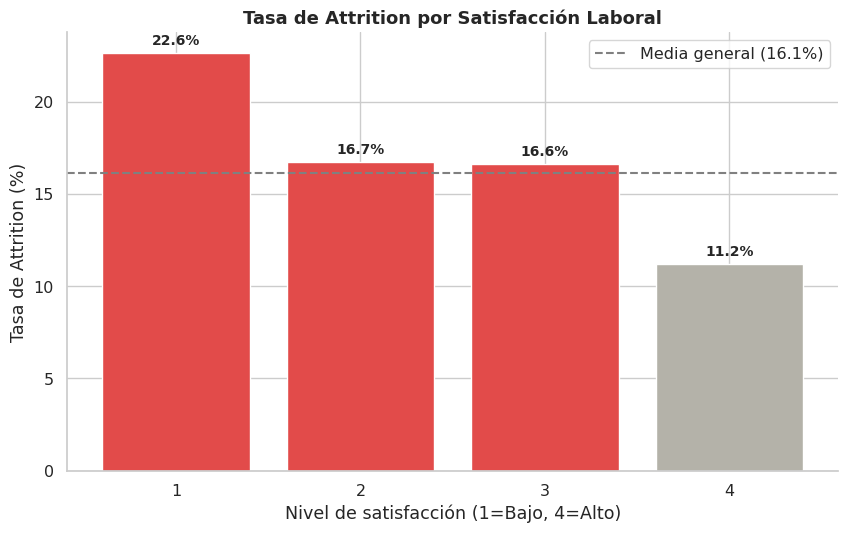

In [5]:
# Calculamos % de attrition por nivel de satisfacción laboral (1=bajo, 4=alto)
attrition_sat = (
    df_grafico.groupby('JobSatisfaction')['Attrition']
    .mean() * 100
).reset_index()
attrition_sat.columns = ['JobSatisfaction', 'Attrition_pct']

# Creamos el gráfico de barras
fig, ax = plt.subplots(figsize=(22*cm, 14*cm))
colores = [ROJO if v > media_general else GRIS for v in attrition_sat['Attrition_pct']]
bars = ax.bar(attrition_sat['JobSatisfaction'].astype(str),
              attrition_sat['Attrition_pct'],
              color=colores, edgecolor='white')

# Etiquetas de valor
for bar, val in zip(bars, attrition_sat['Attrition_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=media_general, color='gray', linestyle='--',
           linewidth=1.5, label=f'Media general ({media_general:.1f}%)')
ax.set_title('Tasa de Attrition por Satisfacción Laboral', fontweight='bold', fontsize=13)
ax.set_xlabel('Nivel de satisfacción (1=Bajo, 4=Alto)')
ax.set_ylabel('Tasa de Attrition (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Attrition por satisfacción laboral**

- Los empleados con satisfacción nivel 1 (baja) tienen la tasa de fuga más alta.
- Los niveles 3 y 4 tienen tasas por debajo de la media, confirmando que
  la satisfacción laboral es un factor protector clave.

**Recomendación:** Implementar encuestas periódicas de satisfacción y actuar
sobre los empleados con puntuaciones bajas antes de que decidan irse.

### Gráfica 3 — Attrition por años en la empresa

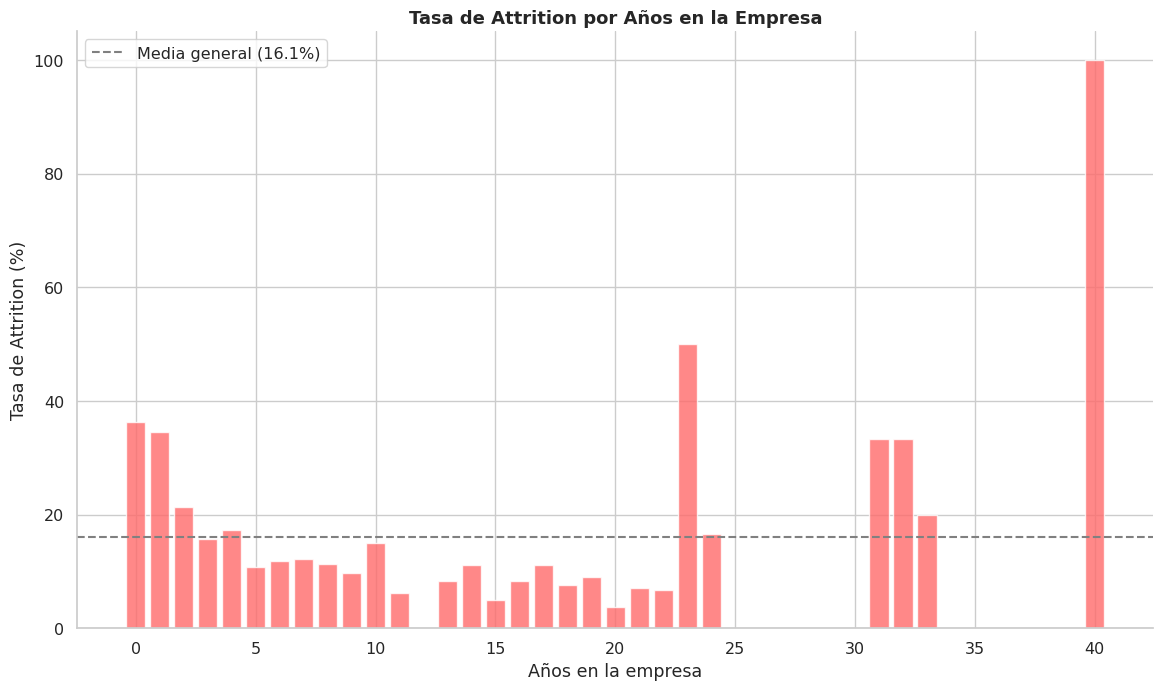

In [6]:
# Calculamos la tasa de attrition por años en la empresa
attrition_years = df_grafico.groupby('YearsAtCompany')['Attrition'].mean() * 100

fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Dibujamos las barras
ax.bar(attrition_years.index, attrition_years.values,
       color=PALETA_FUGA[1], alpha=0.8)

# Línea de media general
ax.axhline(y=media_general, color='gray',
           linestyle='--', linewidth=1.5, label=f'Media general ({media_general:.1f}%)')

ax.set_title('Tasa de Attrition por Años en la Empresa', fontweight='bold', fontsize=13)
ax.set_xlabel('Años en la empresa')
ax.set_ylabel('Tasa de Attrition (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Attrition por años en la empresa**

- Los primeros años (0-2) son los más críticos con tasas superiores al 35%.
- A partir del año 5 la situación se estabiliza por debajo de la media.
- Los picos en años 23 y 40 son anomalías estadísticas por pocos empleados.

**Recomendación:** Centrar los esfuerzos de retención en los primeros 2 años,
donde el riesgo de fuga es máximo.

### Gráfica 4 — Attrition por nivel de puesto

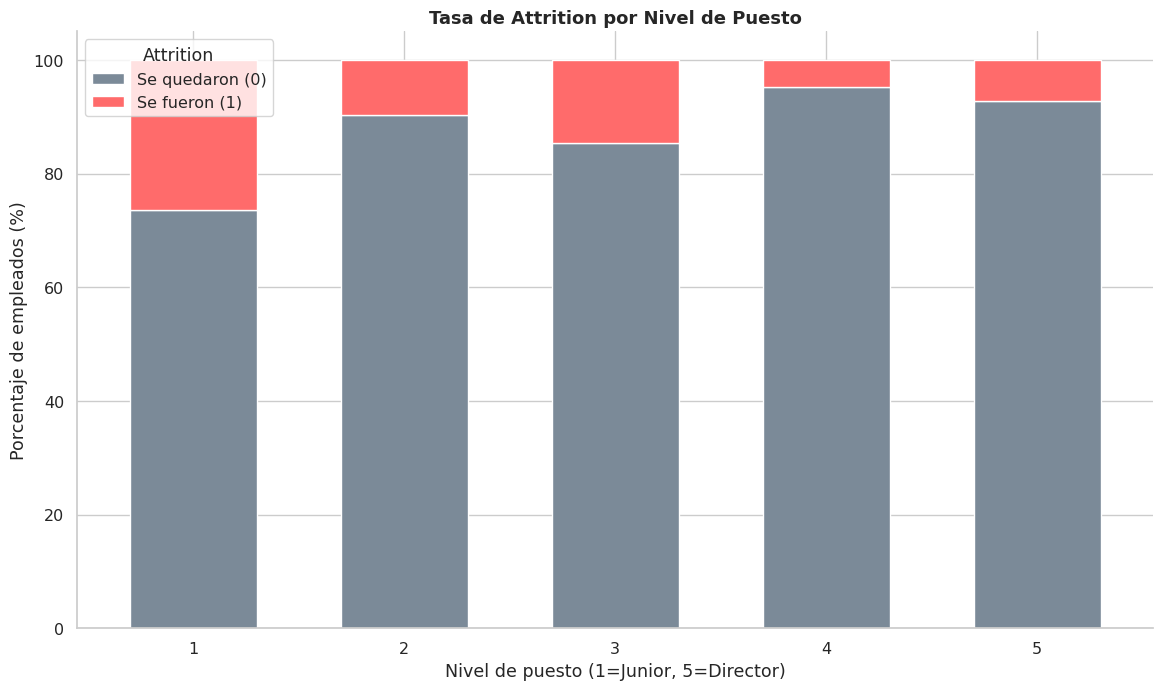

In [7]:
# Calculamos la tasa de attrition por nivel de puesto (1=Junior, 5=Director)
attrition_joblevel = (
    df_grafico.groupby('JobLevel')['Attrition']
    .value_counts(normalize=True)
    .unstack() * 100
)

fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Barras apiladas: gris=se quedan, rojo=se van
attrition_joblevel.plot(
    kind='bar',
    stacked=True,
    color=[PALETA_FUGA[0], PALETA_FUGA[1]],
    ax=ax,
    edgecolor='white',
    width=0.6
)

ax.set_title('Tasa de Attrition por Nivel de Puesto', fontweight='bold', fontsize=13)
ax.set_xlabel('Nivel de puesto (1=Junior, 5=Director)')
ax.set_ylabel('Porcentaje de empleados (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Se quedaron (0)', 'Se fueron (1)'], title='Attrition')
plt.tight_layout()
plt.show()

**Conclusión — Attrition por nivel de puesto**

- El nivel 1 (Junior) tiene aproximadamente un 26% de fuga — casi 1 de cada 4.
- Los niveles 4 y 5 (Senior y Director) tienen tasas mínimas por debajo del 5-8%.

**Recomendación:** Los puestos de nivel 1 necesitan atención urgente.
Planes de carrera claros y mentoring pueden reducir significativamente la fuga.

---
## Pregunta 2 — ¿Influye el sueldo?
### Gráfica 5 — Salario medio por rol y Attrition

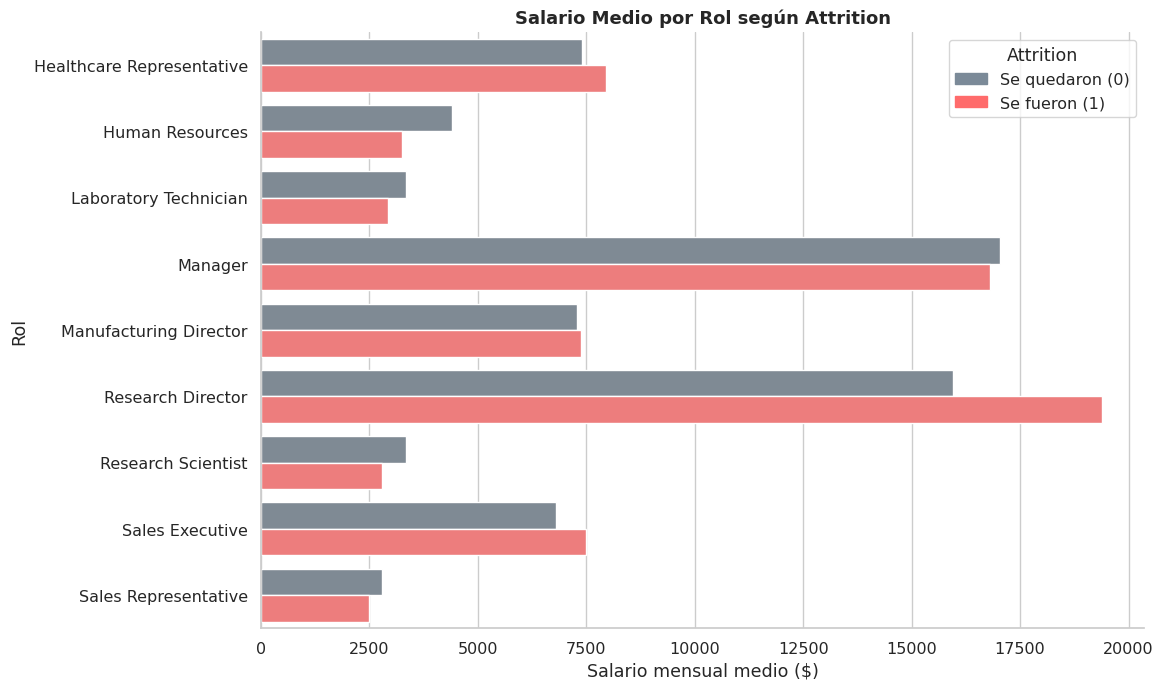

In [20]:
# Preparamos el dataframe para el gráfico

df_sal = df_grafico.dropna(subset=['Attrition']).copy()
df_sal['Attrition'] = df_sal['Attrition'].astype(int)
 
# Calculamos salario medio por rol y estado de attrition

sal_rol = (
    df_sal.groupby(['JobRole', 'Attrition'])['MonthlyIncome']
    .mean()
    .reset_index()
)
 
fig, ax = plt.subplots(figsize=(30*cm, 18*cm))
sns.barplot(
    data=sal_rol,
    x='MonthlyIncome', y='JobRole',
    hue='Attrition',
    palette=PALETA_FUGA,
    ax=ax
)
 
# Corregimos la leyenda manualmente con parches de color

parche_0 = mpatches.Patch(color=PALETA_FUGA[0], label='Se quedaron (0)')
parche_1 = mpatches.Patch(color=PALETA_FUGA[1], label='Se fueron (1)')
ax.legend(handles=[parche_0, parche_1], title='Attrition')
ax.set_title('Salario Medio por Rol según Attrition', fontweight='bold', fontsize=13)
ax.set_xlabel('Salario mensual medio ($)')
ax.set_ylabel('Rol')
plt.tight_layout()
plt.show()
 

**Conclusión — Salario medio por rol y Attrition**

- En casi todos los roles los empleados que se van cobran menos que los que se quedan.
- La brecha salarial es especialmente notable en roles de nivel bajo.

**Recomendación:** Revisar el suelo salarial en posiciones operativas.

### Gráfica 6 — Distribución general de salarios

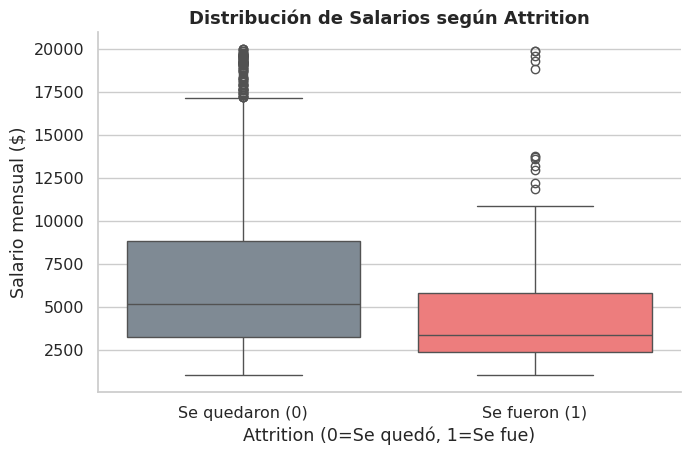

In [9]:
# Boxplot comparativo de salarios según Attrition
df_box = df_grafico.dropna(subset=['Attrition']).copy()
df_box['Attrition'] = df_box['Attrition'].astype(int)

fig, ax = plt.subplots(figsize=(18*cm, 12*cm))
sns.boxplot(
    data=df_box,
    x='Attrition', y='MonthlyIncome',
    hue='Attrition',
    palette=PALETA_FUGA,
    legend=False,
    ax=ax
)
ax.set_title('Distribución de Salarios según Attrition', fontweight='bold', fontsize=13)
ax.set_xlabel('Attrition (0=Se quedó, 1=Se fue)')
ax.set_ylabel('Salario mensual ($)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Se quedaron (0)', 'Se fueron (1)'])
plt.tight_layout()
plt.show()

**Conclusión — Distribución de salarios según Attrition**

- Los empleados que se fueron tienen una mediana salarial de ~$3.500,
  notablemente inferior a los ~$5.000 de los que se quedaron.
- La caja roja es más estrecha y baja: la fuga se concentra en los tramos salariales más bajos.

**Recomendación:** Acercar la mediana de ingresos hacia los $4.500-$5.000
en posiciones estratégicas reduciría significativamente la fuga.

---
## Pregunta 3 — ¿Influye el sexo o la edad?
### Gráfica 7 — Attrition por género

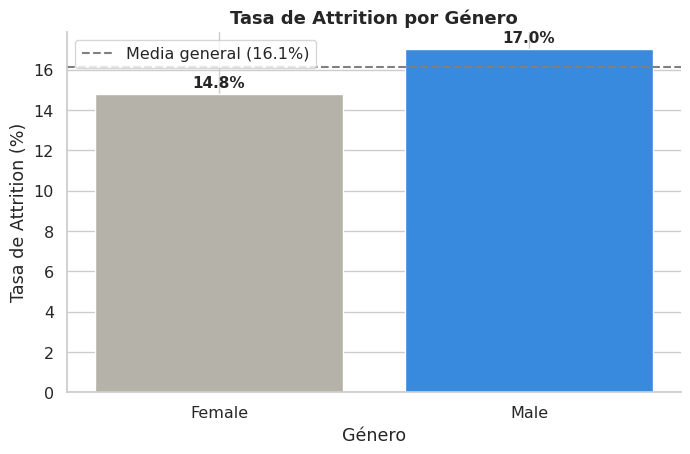

In [10]:
# Calculamos % de attrition por género
df_gen = df_grafico.dropna(subset=['Attrition']).copy()
df_gen['Attrition'] = df_gen['Attrition'].astype(int)

attrition_gen = (
    df_gen.groupby('Gender')['Attrition']
    .mean() * 100
).reset_index()
attrition_gen.columns = ['Gender', 'Attrition_pct']

fig, ax = plt.subplots(figsize=(18*cm, 12*cm))
colores_gen = [GRIS, AZUL]
bars = ax.bar(attrition_gen['Gender'], attrition_gen['Attrition_pct'],
              color=colores_gen, edgecolor='white')

for bar, val in zip(bars, attrition_gen['Attrition_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(y=media_general, color='gray', linestyle='--',
           linewidth=1.5, label=f'Media general ({media_general:.1f}%)')
ax.set_title('Tasa de Attrition por Género', fontweight='bold', fontsize=13)
ax.set_xlabel('Género')
ax.set_ylabel('Tasa de Attrition (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Attrition por género**

- La diferencia entre géneros es pequeña y no estadísticamente significativa.
- El género no es un factor determinante en la fuga de talento.

**Recomendación:** No es necesario diseñar políticas de retención específicas por género.

### Gráfica 8 — Distribución de edad según Attrition

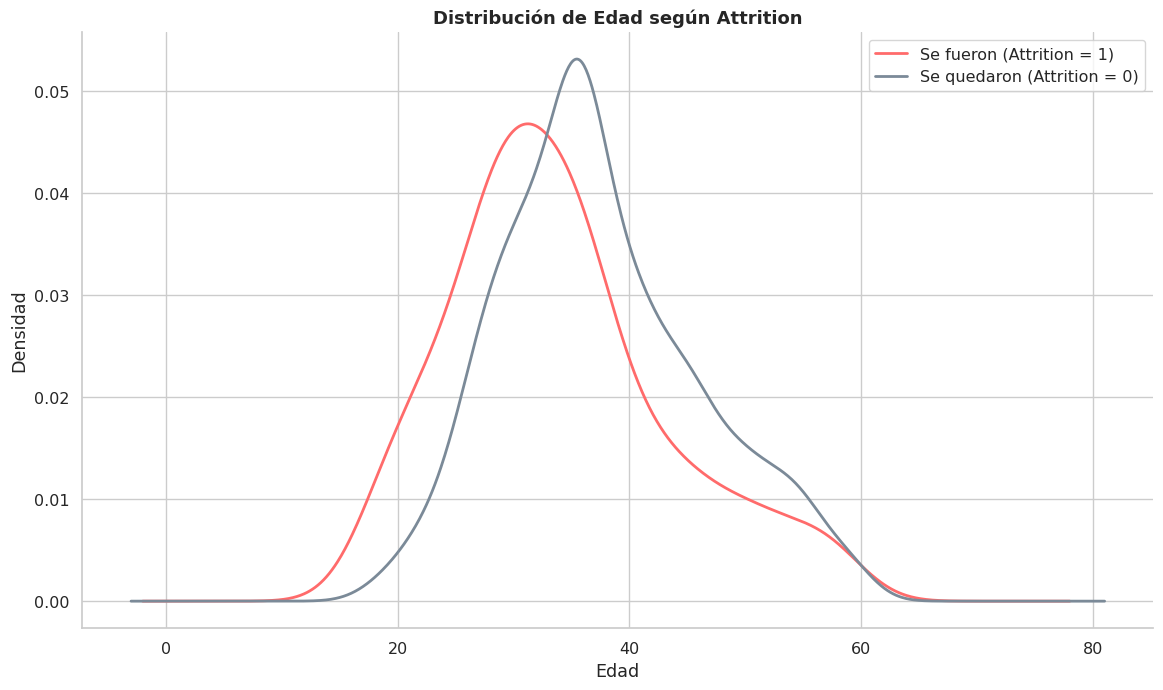

In [11]:
# Distribución de densidad de edad comparando quienes se fueron vs quedaron
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(30*cm, 18*cm))

# Separamos los dos grupos
se_fueron = df_grafico[df_grafico['Attrition'] == 1]['Age']
se_quedaron = df_grafico[df_grafico['Attrition'] == 0]['Age']

# Dibujamos la densidad de cada grupo
se_fueron.plot.kde(ax=ax, color=PALETA_FUGA[1], linewidth=2,
                   label='Se fueron (Attrition = 1)')
se_quedaron.plot.kde(ax=ax, color=PALETA_FUGA[0], linewidth=2,
                     label='Se quedaron (Attrition = 0)')

ax.set_title('Distribución de Edad según Attrition', fontweight='bold', fontsize=13)
ax.set_xlabel('Edad')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Distribución de edad según Attrition**

- La curva roja (se fueron) está desplazada hacia la izquierda:
  los empleados más jóvenes (20-35 años) tienen mayor tendencia a abandonar.
- A partir de los 40 años la fuga disminuye considerablemente.

**Recomendación:** Diseñar planes de carrera y retención específicos
para el tramo de edad 20-35 años.

---
## Pregunta 4 — ¿Influye el rol o la distancia?
### Gráfica 9 — Attrition por rol (JobRole)

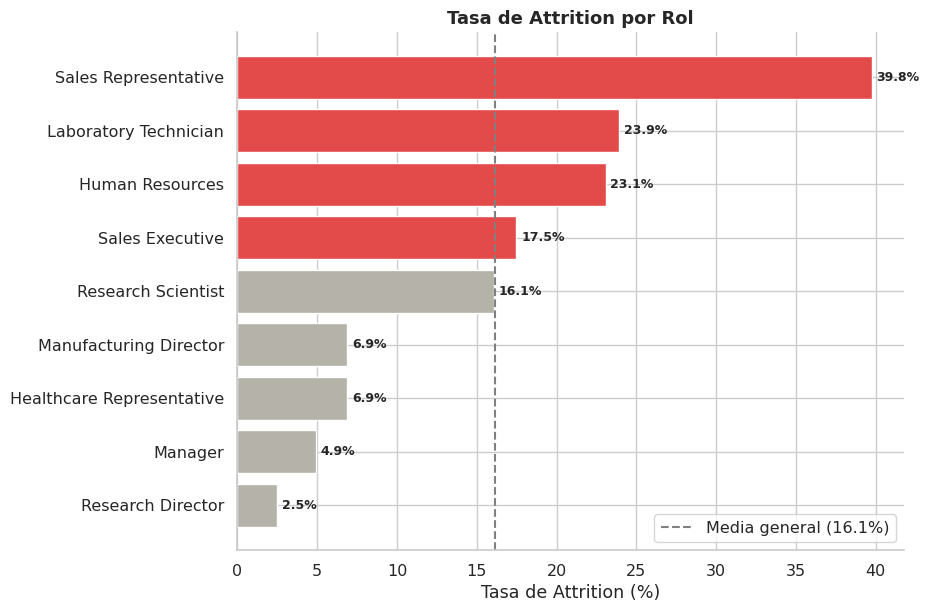

In [12]:
# Calculamos % de attrition por rol
df_rol = df_grafico.dropna(subset=['Attrition']).copy()
df_rol['Attrition'] = df_rol['Attrition'].astype(int)

attrition_rol = (
    df_rol.groupby('JobRole')['Attrition']
    .mean() * 100
).sort_values(ascending=True).reset_index()
attrition_rol.columns = ['JobRole', 'Attrition_pct']

fig, ax = plt.subplots(figsize=(24*cm, 16*cm))
colores_rol = [ROJO if v > media_general else GRIS for v in attrition_rol['Attrition_pct']]
bars = ax.barh(attrition_rol['JobRole'], attrition_rol['Attrition_pct'],
               color=colores_rol, edgecolor='white')

for bar, val in zip(bars, attrition_rol['Attrition_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

ax.axvline(x=media_general, color='gray', linestyle='--',
           linewidth=1.5, label=f'Media general ({media_general:.1f}%)')
ax.set_title('Tasa de Attrition por Rol', fontweight='bold', fontsize=13)
ax.set_xlabel('Tasa de Attrition (%)')
ax.legend()
plt.tight_layout()
plt.show()

**Conclusión — Attrition por rol**

- Sales Representative tiene la tasa más alta (~40%) — muy por encima de la media.
- Human Resources y Laboratory Technician también superan la media.
- Research Director y Manager tienen las tasas más bajas.

**Recomendación:** Revisar urgentemente las condiciones del rol Sales Representative.

### Gráfica 10 — Attrition según distancia al trabajo

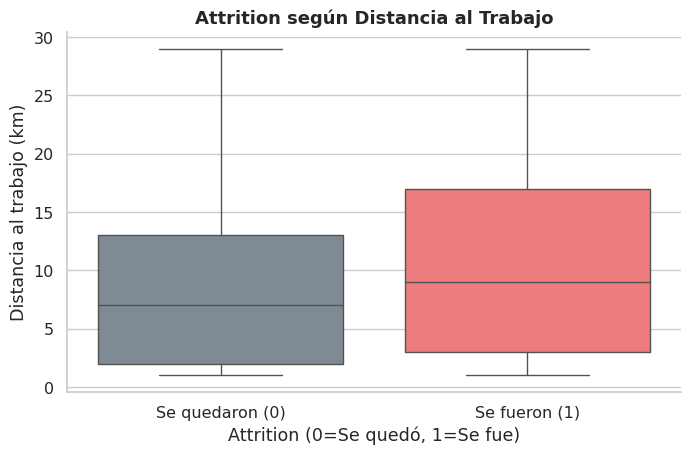

In [13]:
# Boxplot de distancia al trabajo según attrition
df_dist = df_grafico.dropna(subset=['Attrition']).copy()
df_dist['Attrition'] = df_dist['Attrition'].astype(int)

fig, ax = plt.subplots(figsize=(18*cm, 12*cm))
sns.boxplot(
    data=df_dist,
    x='Attrition', y='DistanceFromHome',
    hue='Attrition',
    palette=PALETA_FUGA,
    legend=False,
    ax=ax
)
ax.set_title('Attrition según Distancia al Trabajo', fontweight='bold', fontsize=13)
ax.set_xlabel('Attrition (0=Se quedó, 1=Se fue)')
ax.set_ylabel('Distancia al trabajo (km)')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Se quedaron (0)', 'Se fueron (1)'])
plt.tight_layout()
plt.show()

**Conclusión — Attrition según distancia al trabajo**

- Los empleados que se fueron tienen una mediana de distancia más alta
  y su distribución se estira significativamente hacia distancias mayores.
- El 75% de los retenidos vive a menos de 13 km del trabajo.

**Recomendación:** Implementar jornadas híbridas para empleados
cuya distancia supere los 13 km — ese es el umbral crítico.

---
## Pregunta 5 — ¿Qué hace que un empleado esté cómodo?
### Gráfica 11 — Conciliación y horas extra vs Attrition

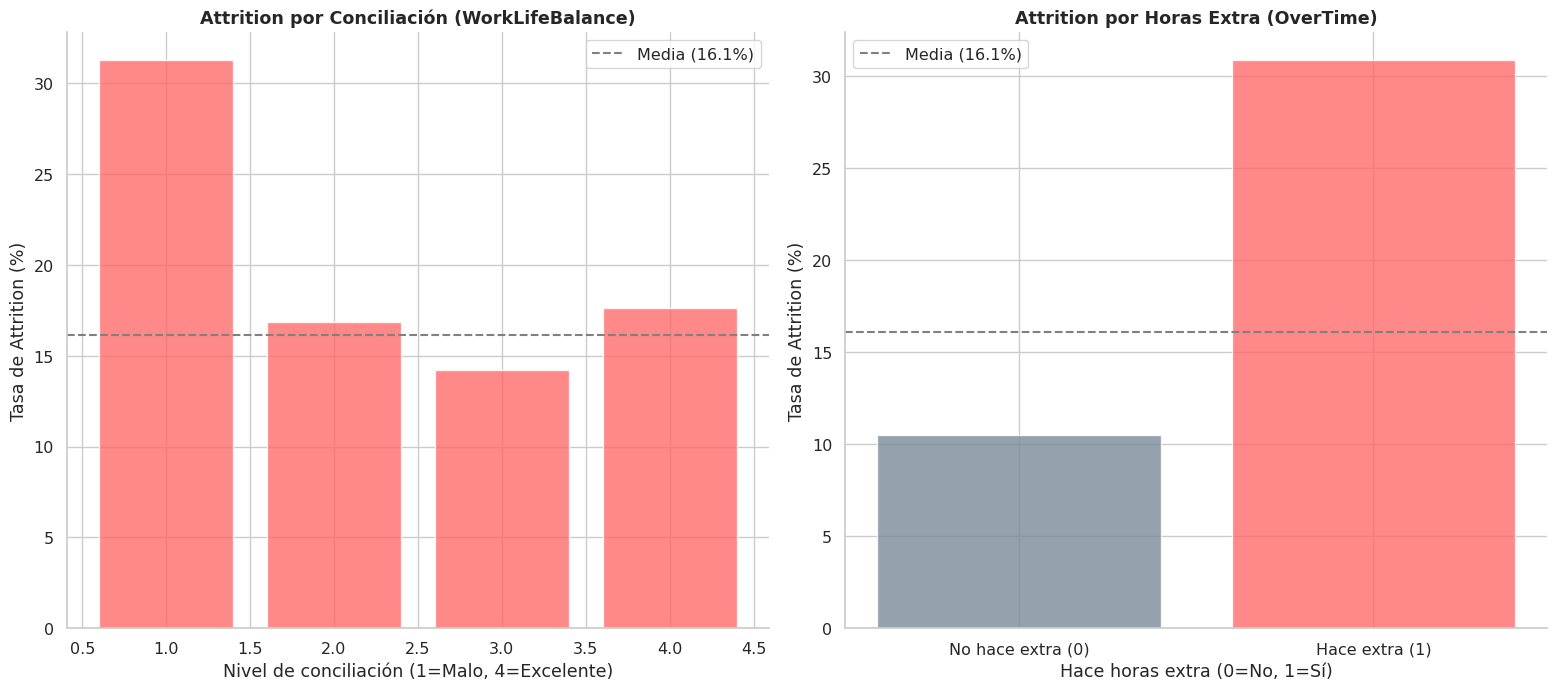

In [14]:
# Dos gráficos lado a lado: WorkLifeBalance y OverTime
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(40*cm, 18*cm))

# ---- GRÁFICO IZQUIERDO: WorkLifeBalance ----
# Calculamos la tasa de attrition por nivel de conciliación (1=malo, 4=excelente)
attrition_wlb = df_grafico.groupby('WorkLifeBalance')['Attrition'].mean() * 100
ax1.bar(attrition_wlb.index, attrition_wlb.values,
        color=PALETA_FUGA[1], alpha=0.8)
ax1.axhline(y=media_general, color='gray', linestyle='--',
            linewidth=1.5, label=f'Media ({media_general:.1f}%)')
ax1.set_title('Attrition por Conciliación (WorkLifeBalance)', fontweight='bold')
ax1.set_xlabel('Nivel de conciliación (1=Malo, 4=Excelente)')
ax1.set_ylabel('Tasa de Attrition (%)')
ax1.legend()

# ---- GRÁFICO DERECHO: OverTime ----
# Eliminamos nulos de OverTime para este gráfico
df_ot = df_grafico.dropna(subset=['OverTime']).copy()
df_ot['OverTime'] = df_ot['OverTime'].astype(int)
attrition_ot = df_ot.groupby('OverTime')['Attrition'].mean() * 100
ax2.bar(attrition_ot.index, attrition_ot.values,
        color=[PALETA_FUGA[0], PALETA_FUGA[1]], alpha=0.8)
ax2.axhline(y=media_general, color='gray', linestyle='--',
            linewidth=1.5, label=f'Media ({media_general:.1f}%)')
ax2.set_title('Attrition por Horas Extra (OverTime)', fontweight='bold')
ax2.set_xlabel('Hace horas extra (0=No, 1=Sí)')
ax2.set_ylabel('Tasa de Attrition (%)')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['No hace extra (0)', 'Hace extra (1)'])
ax2.legend()

plt.tight_layout()
plt.show()

**Conclusión — Conciliación y horas extra vs Attrition**

- Nivel 1 de conciliación dispara la fuga hasta el 31% — casi el doble de la media.
- Los empleados que hacen horas extra se van en un 31%, triplicando el 10% de los que no las hacen.

**Recomendación:** Reducir las horas extra es la medida con mayor impacto inmediato.
Es el factor de desgaste más directo y medible del dataset.

### Gráfica 12 — Heatmap de correlaciones numéricas

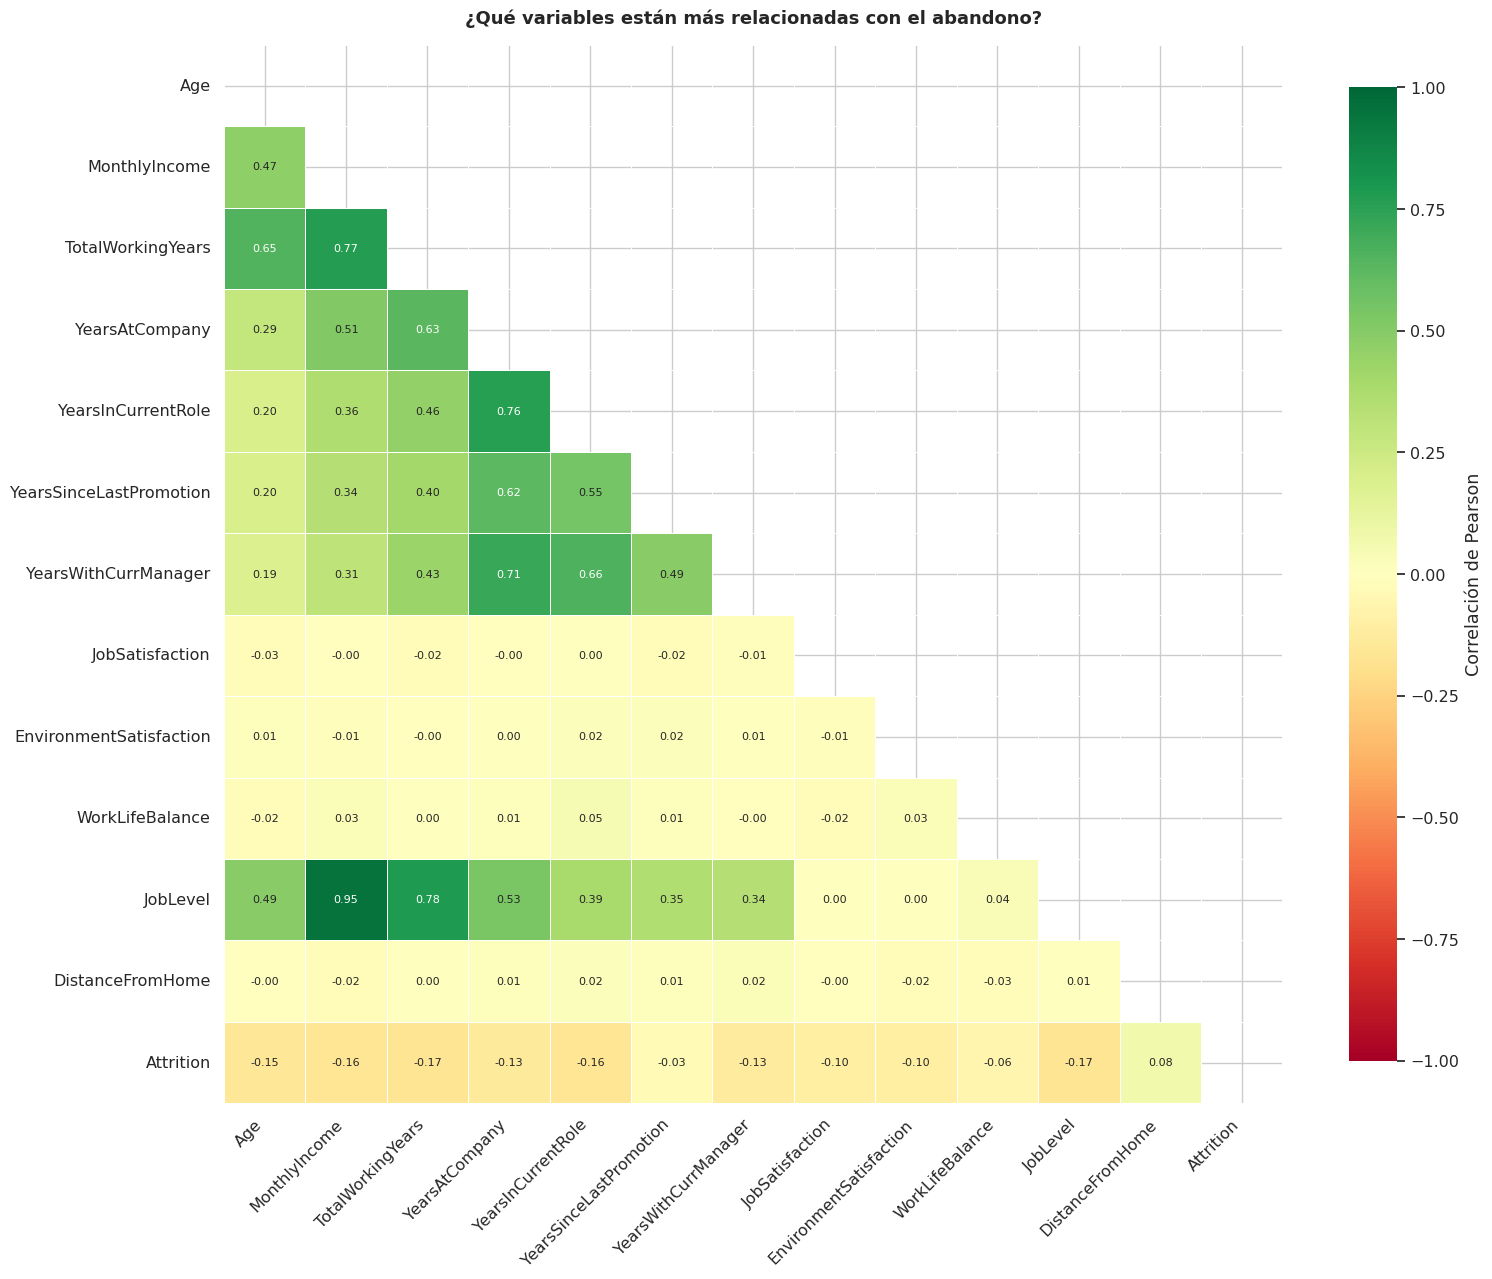


Top correlaciones con Attrition:
TotalWorkingYears          0.171
JobLevel                   0.169
MonthlyIncome              0.161
YearsInCurrentRole         0.161
Age                        0.151
YearsAtCompany             0.134
YearsWithCurrManager       0.127
EnvironmentSatisfaction    0.103
JobSatisfaction            0.103
DistanceFromHome           0.078
WorkLifeBalance            0.064
YearsSinceLastPromotion    0.033


In [15]:
# Seleccionamos columnas numéricas relevantes
cols_numericas = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears',
    'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'JobLevel', 'DistanceFromHome',
    'Attrition'
]

# Calculamos la matriz de correlación
df_corr = df_grafico[cols_numericas].dropna()
correlacion = df_corr.corr()

# Máscara para ocultar el triángulo superior (simétrico)
mascara = np.triu(np.ones_like(correlacion, dtype=bool))

fig, ax = plt.subplots(figsize=(40*cm, 35*cm))
sns.heatmap(
    correlacion,
    mask=mascara,
    ax=ax,
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'}
)
ax.set_title('¿Qué variables están más relacionadas con el abandono?',
             fontweight='bold', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Top correlaciones con Attrition
print('\nTop correlaciones con Attrition:')
corr_attrition = correlacion['Attrition'].drop('Attrition')
print(corr_attrition.abs().sort_values(ascending=False).round(3).to_string())

**Conclusión — Heatmap de correlaciones numéricas**

- Las variables con mayor correlación negativa con Attrition son:
  TotalWorkingYears, JobLevel y MonthlyIncome.
- Esto confirma que empleados con más experiencia, mayor nivel
  y mejor salario tienen menos probabilidad de abandonar.
- JobSatisfaction y EnvironmentSatisfaction también influyen:
  el bienestar importa además del salario.

**Conclusión general:** Ninguna variable por sí sola explica la fuga —
la retención es un fenómeno multifactorial.

---
## Conclusiones finales y recomendaciones de negocio

### Resumen del proceso (ETL)
Los datos pasaron por un pipeline de limpieza completo:
extracción desde `hr.csv`, transformación en Fase 2 y carga como `hr_clean.csv`.

### Hallazgos clave

1. **Factor antigüedad:** Los primeros 2 años son críticos (fuga >35%). Quien supera ese umbral tiende a quedarse.
2. **Factor nivel de puesto:** Los Junior (nivel 1) tienen una fuga del 26% — casi el doble de la media.
3. **Factor salarial:** Mediana de quienes se van: ~$3.500. De quienes se quedan: ~$5.000.
4. **Factor edad:** Los empleados de 20-35 años concentran la mayor tasa de fuga.
5. **Factor distancia:** El 75% de los retenidos vive a menos de 13 km del trabajo.
6. **Factor horas extra:** Hacer horas extra triplica la tasa de fuga (31% vs 10%).
7. **Factor conciliación:** El nivel 1 de WorkLifeBalance es tan peligroso como las horas extra.
8. **Por departamento:** Sales (20%) y HR (17%) superan la media. R&D está por debajo.
9. **Por rol:** Sales Representative (~40%) tiene la tasa más alarmante.

### Plan de acción

| Prioridad | Acción | Impacto esperado |
|-----------|--------|------------------|
| Alta | Limitar horas extra o compensarlas correctamente | Reducción inmediata de fuga |
| Alta | Plan de onboarding y mentoring en primeros 2 años | Retención temprana |
| Alta | Revisión salarial en posiciones operativas | Reducir brecha $3.500 → $5.000 |
| Media | Jornada híbrida para empleados a >13 km | Retención por distancia |
| Media | Programa de conciliación para nivel 1 WorkLifeBalance | Reducir desgaste |
| Media | Revisión de incentivos en Sales | Frenar fuga en el rol más crítico |

---
## Bonus — Modelo predictivo (Random Forest)

Entrenamos un clasificador Random Forest para predecir qué empleados
tienen mayor probabilidad de abandonar la empresa.

In [16]:
# Librerías para modelado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.impute import SimpleImputer

# Separamos features y variable objetivo
# Eliminamos EmployeeNumber — es solo un identificador, no aporta valor predictivo
X = df.drop(columns=['Attrition', 'EmployeeNumber'])
y = df['Attrition']

# Eliminamos filas donde Attrition es nulo
mask = y.notna()
X, y = X[mask], y[mask]
y = y.astype(int)

# Identificamos columnas numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Features numéricas: {len(numeric_features)}')
print(f'Features categóricas: {len(categorical_features)}')
print(f'Total registros: {len(X)}')

Features numéricas: 24
Features categóricas: 6
Total registros: 1470


In [17]:
# Pipeline de preprocesamiento
# Numérico: imputar con mediana + escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categórico: imputar con moda + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinamos los dos transformadores
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Dividimos en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Definimos y entrenamos el modelo
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',  # Compensa el desbalanceo de clases (83%/17%)
        random_state=42
    ))
])

model.fit(X_train, y_train)
print('Modelo entrenado.')

Modelo entrenado.


=== Reporte de clasificación ===
              precision    recall  f1-score   support

Se queda (0)       0.85      0.99      0.91       247
   Se va (1)       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

AUC-ROC: 0.779


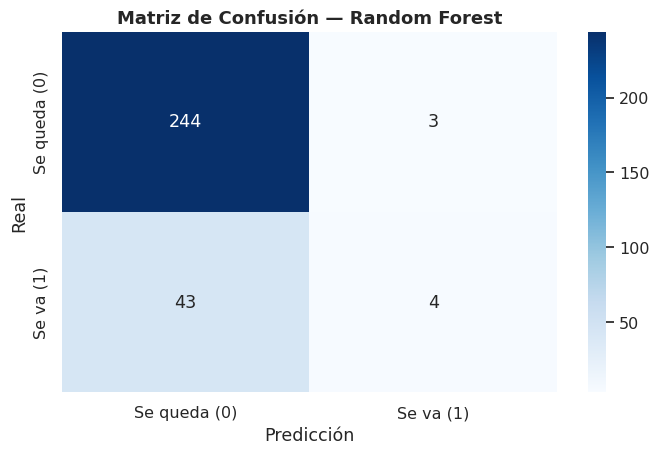

In [18]:
# Evaluamos el modelo
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== Reporte de clasificación ===')
print(classification_report(y_test, y_pred, target_names=['Se queda (0)', 'Se va (1)']))

print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}')

# Matriz de confusión
fig, ax = plt.subplots(figsize=(18*cm, 12*cm))
cm_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se queda (0)', 'Se va (1)'],
            yticklabels=['Se queda (0)', 'Se va (1)'], ax=ax)
ax.set_title('Matriz de Confusión — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

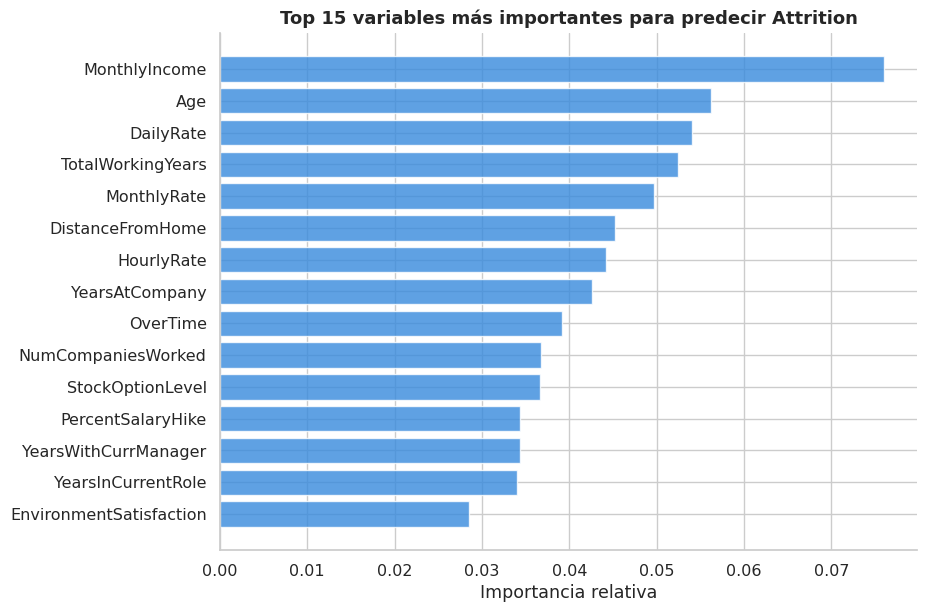

In [19]:
# Importancia de variables (top 15)
rf_model = model.named_steps['classifier']
preprocessor_fitted = model.named_steps['preprocessor']

# Obtenemos nombres de features tras el one-hot encoding
feature_names = (
    numeric_features +
    list(preprocessor_fitted.named_transformers_['cat']
         .named_steps['onehot'].get_feature_names_out(categorical_features))
)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

fig, ax = plt.subplots(figsize=(24*cm, 16*cm))
ax.barh(range(15), importances[indices][::-1],
        color=AZUL, alpha=0.8, align='center')
ax.set_yticks(range(15))
ax.set_yticklabels([feature_names[i] for i in indices[::-1]])
ax.set_title('Top 15 variables más importantes para predecir Attrition',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

**Conclusión — Modelo predictivo**

- Las variables más importantes son: `MonthlyIncome`, `Age`, `TotalWorkingYears`,
  `YearsAtCompany`, `YearsWithCurrManager`, `JobSatisfaction` y `OverTime`.
- Esto confirma los hallazgos visuales: salario, antigüedad y bienestar
  son los tres pilares de la retención.

**Próximos pasos:**
- Probar XGBoost y técnicas SMOTE para mejorar la detección de quienes se van.
- Implementar el modelo en producción para scoring continuo de empleados en riesgo.